# Stage 06 — H3 behavioural response to PM₂.₅ context

## Main research question

**When regional air quality changes, where does observed activity decrease, persist, or increase?**

This notebook keeps the **Locomizer H3 grid as the primary spatial unit**.

It uses:
- Stage 05 H3-level Locomizer footfall change;
- FMI station-based regional PM₂.₅ context;
- CAFEIN neighbourhoods only as a secondary summary geography.

CAFEIN route optimization is deliberately moved out of the centre of the analysis. The purpose here is to characterize **observed behavioural response first**.

Core measures:

\[
\%\Delta Footfall_h =
100 \times \frac{F_{h,B}-F_{h,A}}{F_{h,A}}
\]

\[
PersistenceRatio_h = \frac{F_{h,B}}{F_{h,A}}
\]

These are descriptive indicators, not causal proof of adaptation to pollution.


## 1. Imports and paths

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import cafein.sampledata.helsinki as helsinki

PROJECT_ROOT = Path("/scratch/project_2010417")

STAGE05_DIR_CANDIDATES = [
    Path("../outputs/v3/05_locomizer_station_pm25"),
    PROJECT_ROOT / "paper3" / "outputs" / "v3" / "05_locomizer_station_pm25",
]

STAGE05_GPKG_NAME = "locomizer_two_time_station_pm25_context.gpkg"
STAGE05_SUMMARY_NAME = "locomizer_pm25_two_time_summary.csv"

PM25_CANDIDATE_PAIRS = (
    PROJECT_ROOT
    / "paper3"
    / "airqualityontario22-25"
    / "HMA_pm25"
    / "derived"
    / "hma_pm25_same_hour_candidate_pairs.csv"
)

OUTPUT_DIR = Path("../outputs/v3/06_h3_behavioural_response")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

STABLE_THRESHOLD_PCT = 5.0

print("Output:", OUTPUT_DIR.resolve())


Output: /scratch/project_2010417/paper3/airqualityontario22-25/cafein-helsinki-exposure-poc/outputs/v3/06_h3_behavioural_response


### H3 tessellated map helper

The goal here is to make H3 look like a **continuous spatial surface**, similar to a raster/grid map.

Important differences from the previous version:

- true H3 resolution-10 polygons are preserved;
- polygons are completely filled;
- cell borders are removed by default;
- the plot uses a projected CRS;
- the extent is cropped tightly to observed H3 coverage;
- a higher DPI is used so the individual cells do not collapse visually into point-like marks.

This gives a map closer to the grid-cell appearance in the reference figure while retaining the actual H3 geometry.


In [2]:
def plot_h3_surface(
    gdf,
    column,
    title,
    legend_label,
    cmap=None,
    categorical=False,
    vmin=None,
    vmax=None,
    figsize=(12, 10),
    dpi=180,
    show_cell_edges=False,
):
    data = gdf.dropna(subset=[column]).copy()

    # Project to the Finnish national metric CRS.
    data_proj = data.to_crs("EPSG:3067")

    fig, ax = plt.subplots(
        figsize=figsize,
        dpi=dpi,
    )

    plot_kwargs = {
        "ax": ax,
        "column": column,
        "legend": True,
        "linewidth": 0 if not show_cell_edges else 0.08,
        "edgecolor": "none" if not show_cell_edges else "white",
    }

    if cmap is not None:
        plot_kwargs["cmap"] = cmap

    if categorical:
        plot_kwargs["categorical"] = True
    else:
        if vmin is not None:
            plot_kwargs["vmin"] = vmin
        if vmax is not None:
            plot_kwargs["vmax"] = vmax

        plot_kwargs["legend_kwds"] = {
            "label": legend_label
        }

    data_proj.plot(**plot_kwargs)

    # Tight extent around the observed H3 coverage.
    minx, miny, maxx, maxy = data_proj.total_bounds

    pad_x = (maxx - minx) * 0.01
    pad_y = (maxy - miny) * 0.01

    ax.set_xlim(
        minx - pad_x,
        maxx + pad_x,
    )
    ax.set_ylim(
        miny - pad_y,
        maxy + pad_y,
    )

    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_axis_off()

    plt.tight_layout()
    plt.show()


## 2. Locate Stage 05 outputs

In [3]:
def first_existing_file(directory_candidates, filename, required=True):
    checked = []
    for directory in directory_candidates:
        path = directory / filename
        checked.append(path)
        if path.exists():
            print("Using:", path.resolve())
            return path

    if required:
        raise FileNotFoundError(
            "Could not find required file. Checked:\n"
            + "\n".join(str(p) for p in checked)
        )
    return None

stage05_gpkg = first_existing_file(
    STAGE05_DIR_CANDIDATES,
    STAGE05_GPKG_NAME,
)

stage05_summary_csv = first_existing_file(
    STAGE05_DIR_CANDIDATES,
    STAGE05_SUMMARY_NAME,
)


Using: /scratch/project_2010417/paper3/airqualityontario22-25/cafein-helsinki-exposure-poc/outputs/v3/05_locomizer_station_pm25/locomizer_two_time_station_pm25_context.gpkg
Using: /scratch/project_2010417/paper3/airqualityontario22-25/cafein-helsinki-exposure-poc/outputs/v3/05_locomizer_station_pm25/locomizer_pm25_two_time_summary.csv


## 3. Load H3-level Locomizer response

In [4]:
h3_change = gpd.read_file(
    stage05_gpkg,
    layer="h3_footfall_pm25_context",
)

expected = {
    "CODE",
    "footfall_A",
    "footfall_B",
    "delta_footfall",
    "pct_change_footfall",
    "regional_pm25_A_median",
    "regional_pm25_B_median",
    "regional_delta_pm25_median",
}

missing = expected.difference(h3_change.columns)

if missing:
    raise ValueError(
        "Stage 05 is missing expected columns: "
        + ", ".join(sorted(missing))
    )

print("H3 cells:", len(h3_change))
print("CRS:", h3_change.crs)

display(h3_change.head())


H3 cells: 4873
CRS: EPSG:4326


,CODE,footfall_A,footfall_B,delta_footfall,pct_change_footfall,regional_pm25_A_median,regional_pm25_B_median,regional_delta_pm25_median,response_class,geometry
0,8a08996d4c67fff,1,3,2,200.0,9.6,6.75,-2.85,footfall increased while regional PM2.5 improved,"POLYGON ((24.81277 60.26544, 24.81357 60.265, ..."
1,8a1126d3381ffff,5,5,0,0.0,9.6,6.75,-2.85,footfall stable while regional PM2.5 improved,"POLYGON ((24.93321 60.16945, 24.93401 60.16901..."
2,8a1126d0e277fff,1,1,0,0.0,9.6,6.75,-2.85,footfall stable while regional PM2.5 improved,"POLYGON ((25.03799 60.23481, 25.03879 60.23437..."
3,8a08996a8797fff,3,3,0,0.0,9.6,6.75,-2.85,footfall stable while regional PM2.5 improved,"POLYGON ((24.71006 60.23679, 24.71086 60.23635..."
4,8a1126d2922ffff,2,6,4,200.0,9.6,6.75,-2.85,footfall increased while regional PM2.5 improved,"POLYGON ((24.9754 60.28421, 24.9762 60.28377, ..."


## 4. Add behavioural-response indicators

In [5]:
h3 = h3_change.copy()

h3["persistence_ratio"] = np.where(
    h3["footfall_A"] > 0,
    h3["footfall_B"] / h3["footfall_A"],
    np.nan,
)

h3["absolute_activity_change"] = (
    h3["footfall_B"] - h3["footfall_A"]
)

h3["absolute_activity_loss"] = np.where(
    h3["absolute_activity_change"] < 0,
    -h3["absolute_activity_change"],
    0,
)

h3["absolute_activity_gain"] = np.where(
    h3["absolute_activity_change"] > 0,
    h3["absolute_activity_change"],
    0,
)

def classify_behavior(pct):
    if pd.isna(pct):
        return "missing"
    if pct < -STABLE_THRESHOLD_PCT:
        return "decreased"
    if pct > STABLE_THRESHOLD_PCT:
        return "increased"
    return "broadly stable"

h3["behavior_class"] = h3["pct_change_footfall"].map(classify_behavior)

display(
    h3[
        [
            "CODE",
            "footfall_A",
            "footfall_B",
            "pct_change_footfall",
            "persistence_ratio",
            "absolute_activity_loss",
            "absolute_activity_gain",
            "behavior_class",
        ]
    ].head()
)


,CODE,footfall_A,footfall_B,pct_change_footfall,persistence_ratio,absolute_activity_loss,absolute_activity_gain,behavior_class
0,8a08996d4c67fff,1,3,200.0,3.0,0,2,increased
1,8a1126d3381ffff,5,5,0.0,1.0,0,0,broadly stable
2,8a1126d0e277fff,1,1,0.0,1.0,0,0,broadly stable
3,8a08996a8797fff,3,3,0.0,1.0,0,0,broadly stable
4,8a1126d2922ffff,2,6,200.0,3.0,0,4,increased


## 5. Event-level PM₂.₅ context

The PM₂.₅ input is still a **regional station-network context** from Stage 05.

Every H3 cell shares the same event-level PM₂.₅ direction. These are not H3-specific PM₂.₅ concentrations.


In [6]:
event_pm25 = pd.DataFrame(
    {
        "metric": [
            "regional PM2.5 median — Time A",
            "regional PM2.5 median — Time B",
            "regional PM2.5 median change",
        ],
        "value": [
            h3["regional_pm25_A_median"].dropna().iloc[0],
            h3["regional_pm25_B_median"].dropna().iloc[0],
            h3["regional_delta_pm25_median"].dropna().iloc[0],
        ],
    }
)

display(event_pm25)


,metric,value
0,regional PM2.5 median — Time A,9.60
1,regional PM2.5 median — Time B,6.75
2,regional PM2.5 median change,-2.85


## 6. Map H3 percentage footfall change

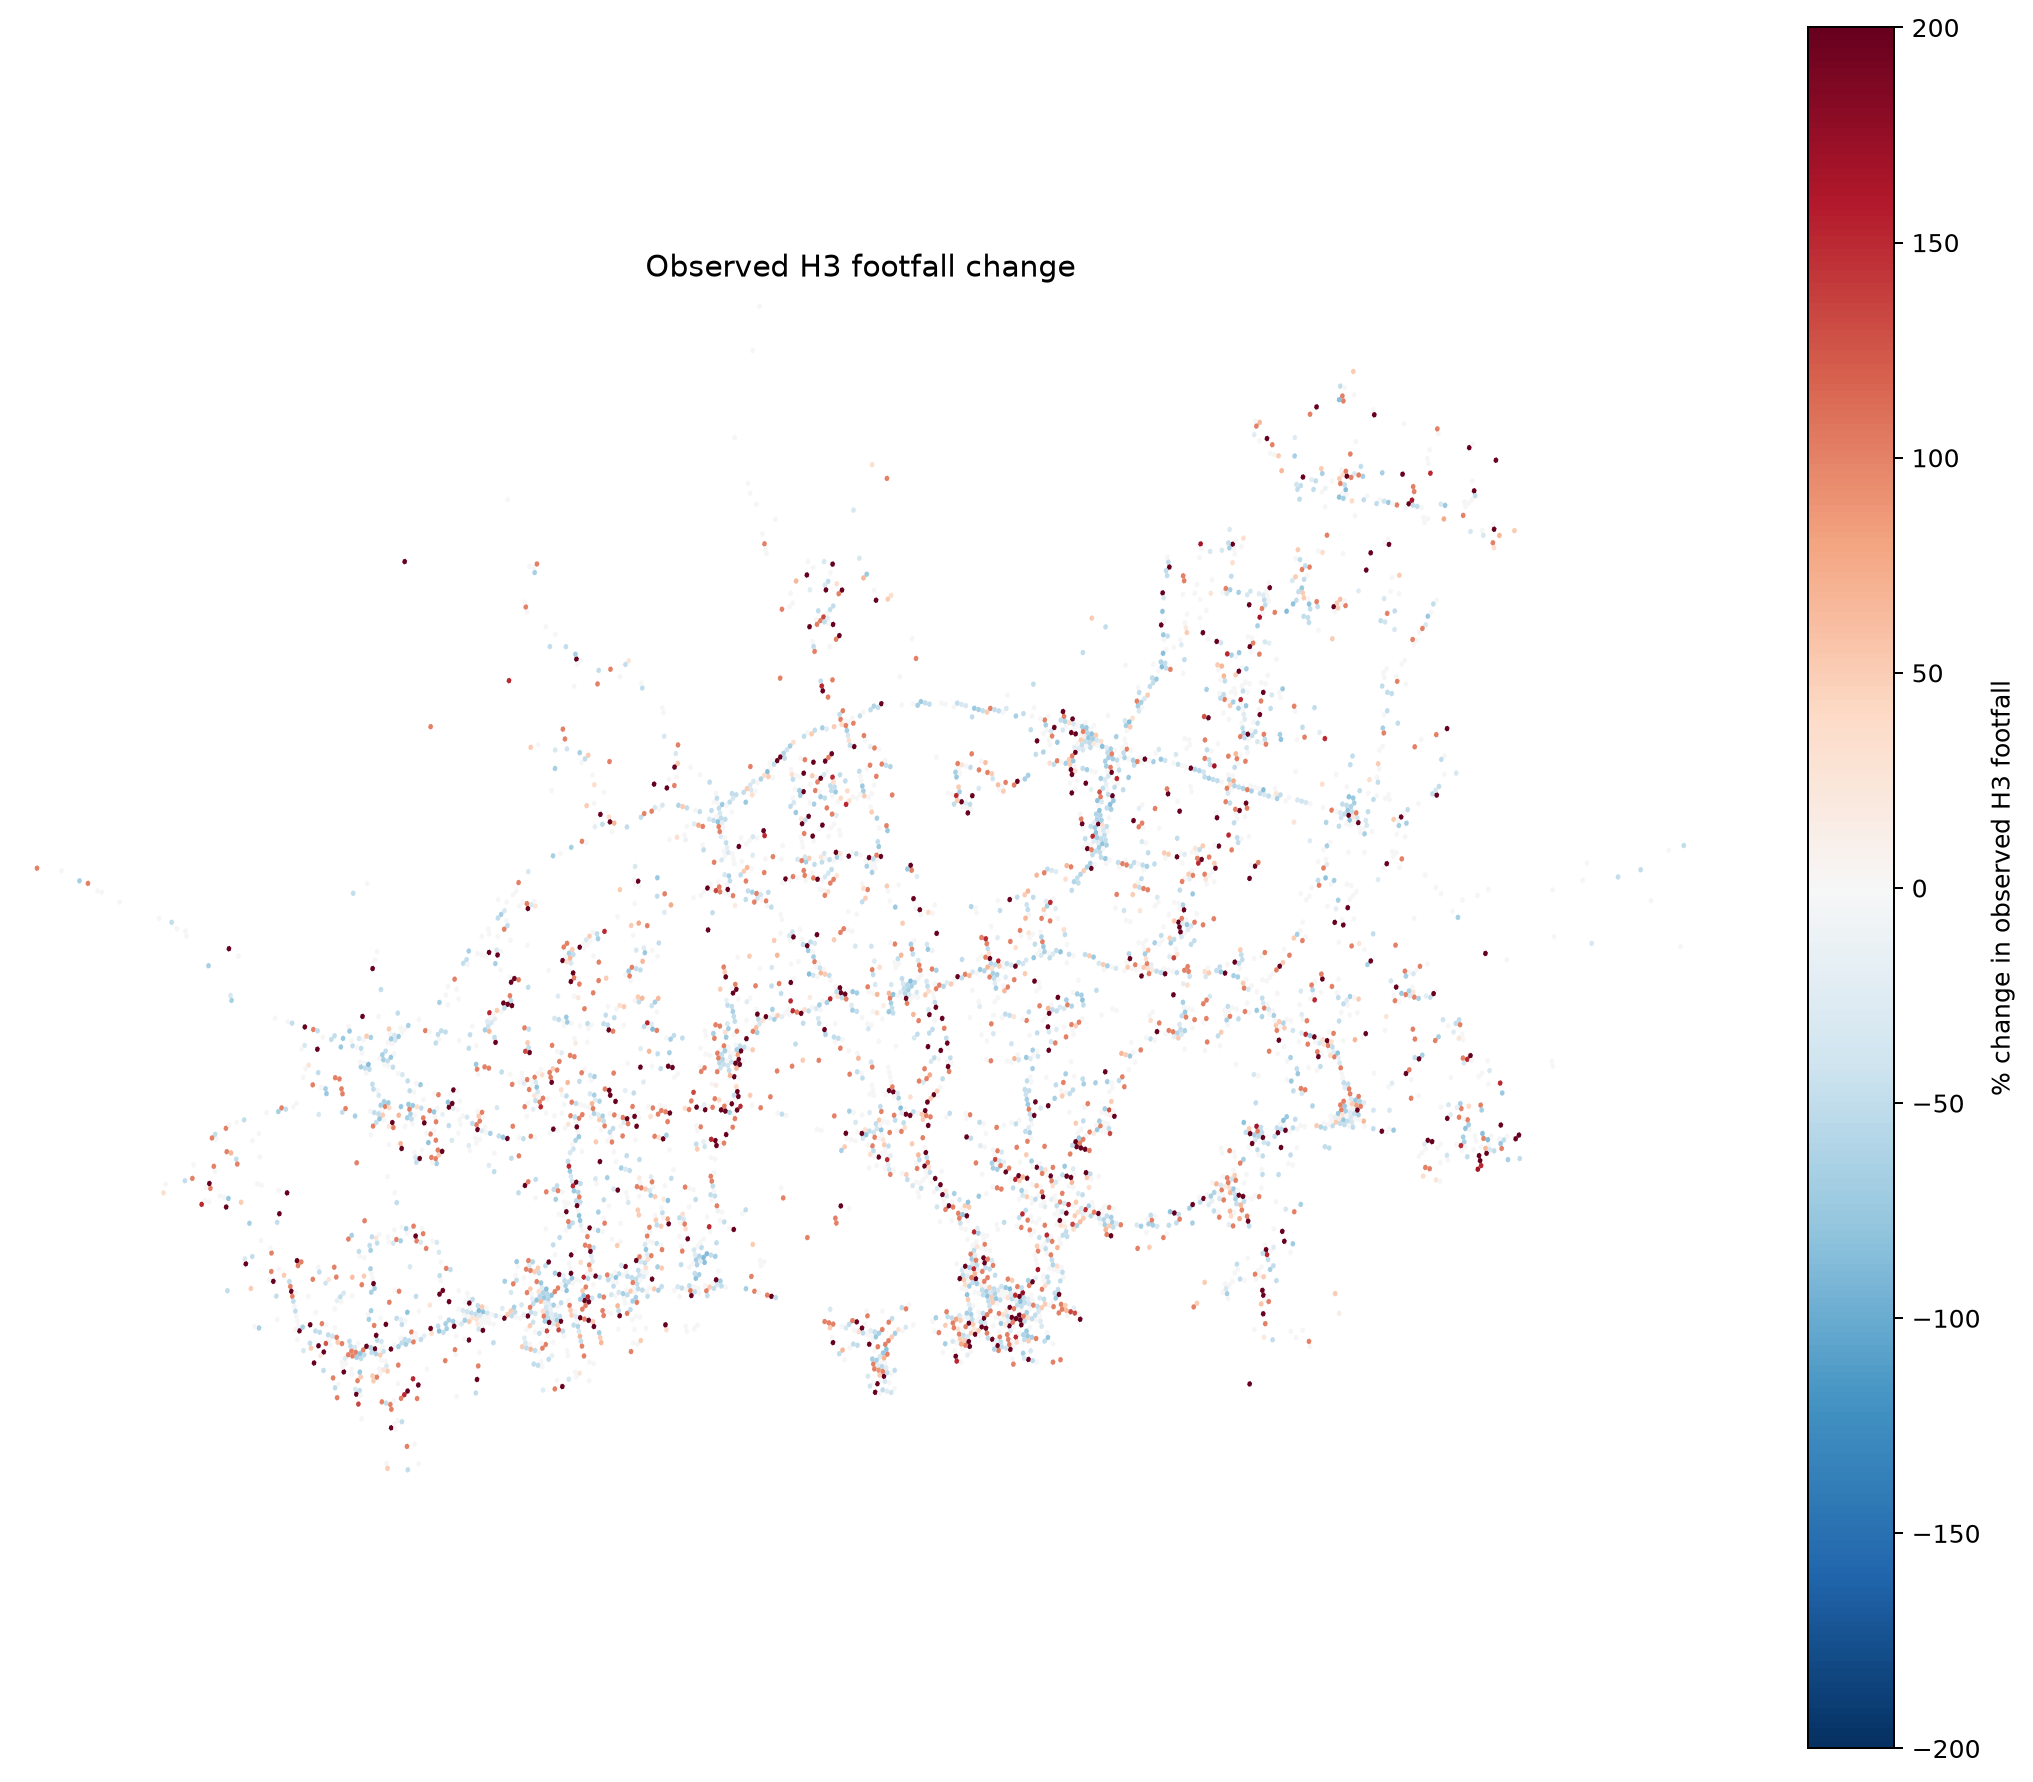

In [7]:
plot_data = h3.dropna(
    subset=["pct_change_footfall"]
).copy()

limit = np.nanpercentile(
    np.abs(plot_data["pct_change_footfall"]),
    95,
)

if not np.isfinite(limit) or limit == 0:
    limit = 1

plot_h3_surface(
    plot_data,
    column="pct_change_footfall",
    title="Observed H3 footfall change",
    legend_label="% change in observed H3 footfall",
    cmap="RdBu_r",
    vmin=-limit,
    vmax=limit,
)


## 7. Map H3 persistence ratio

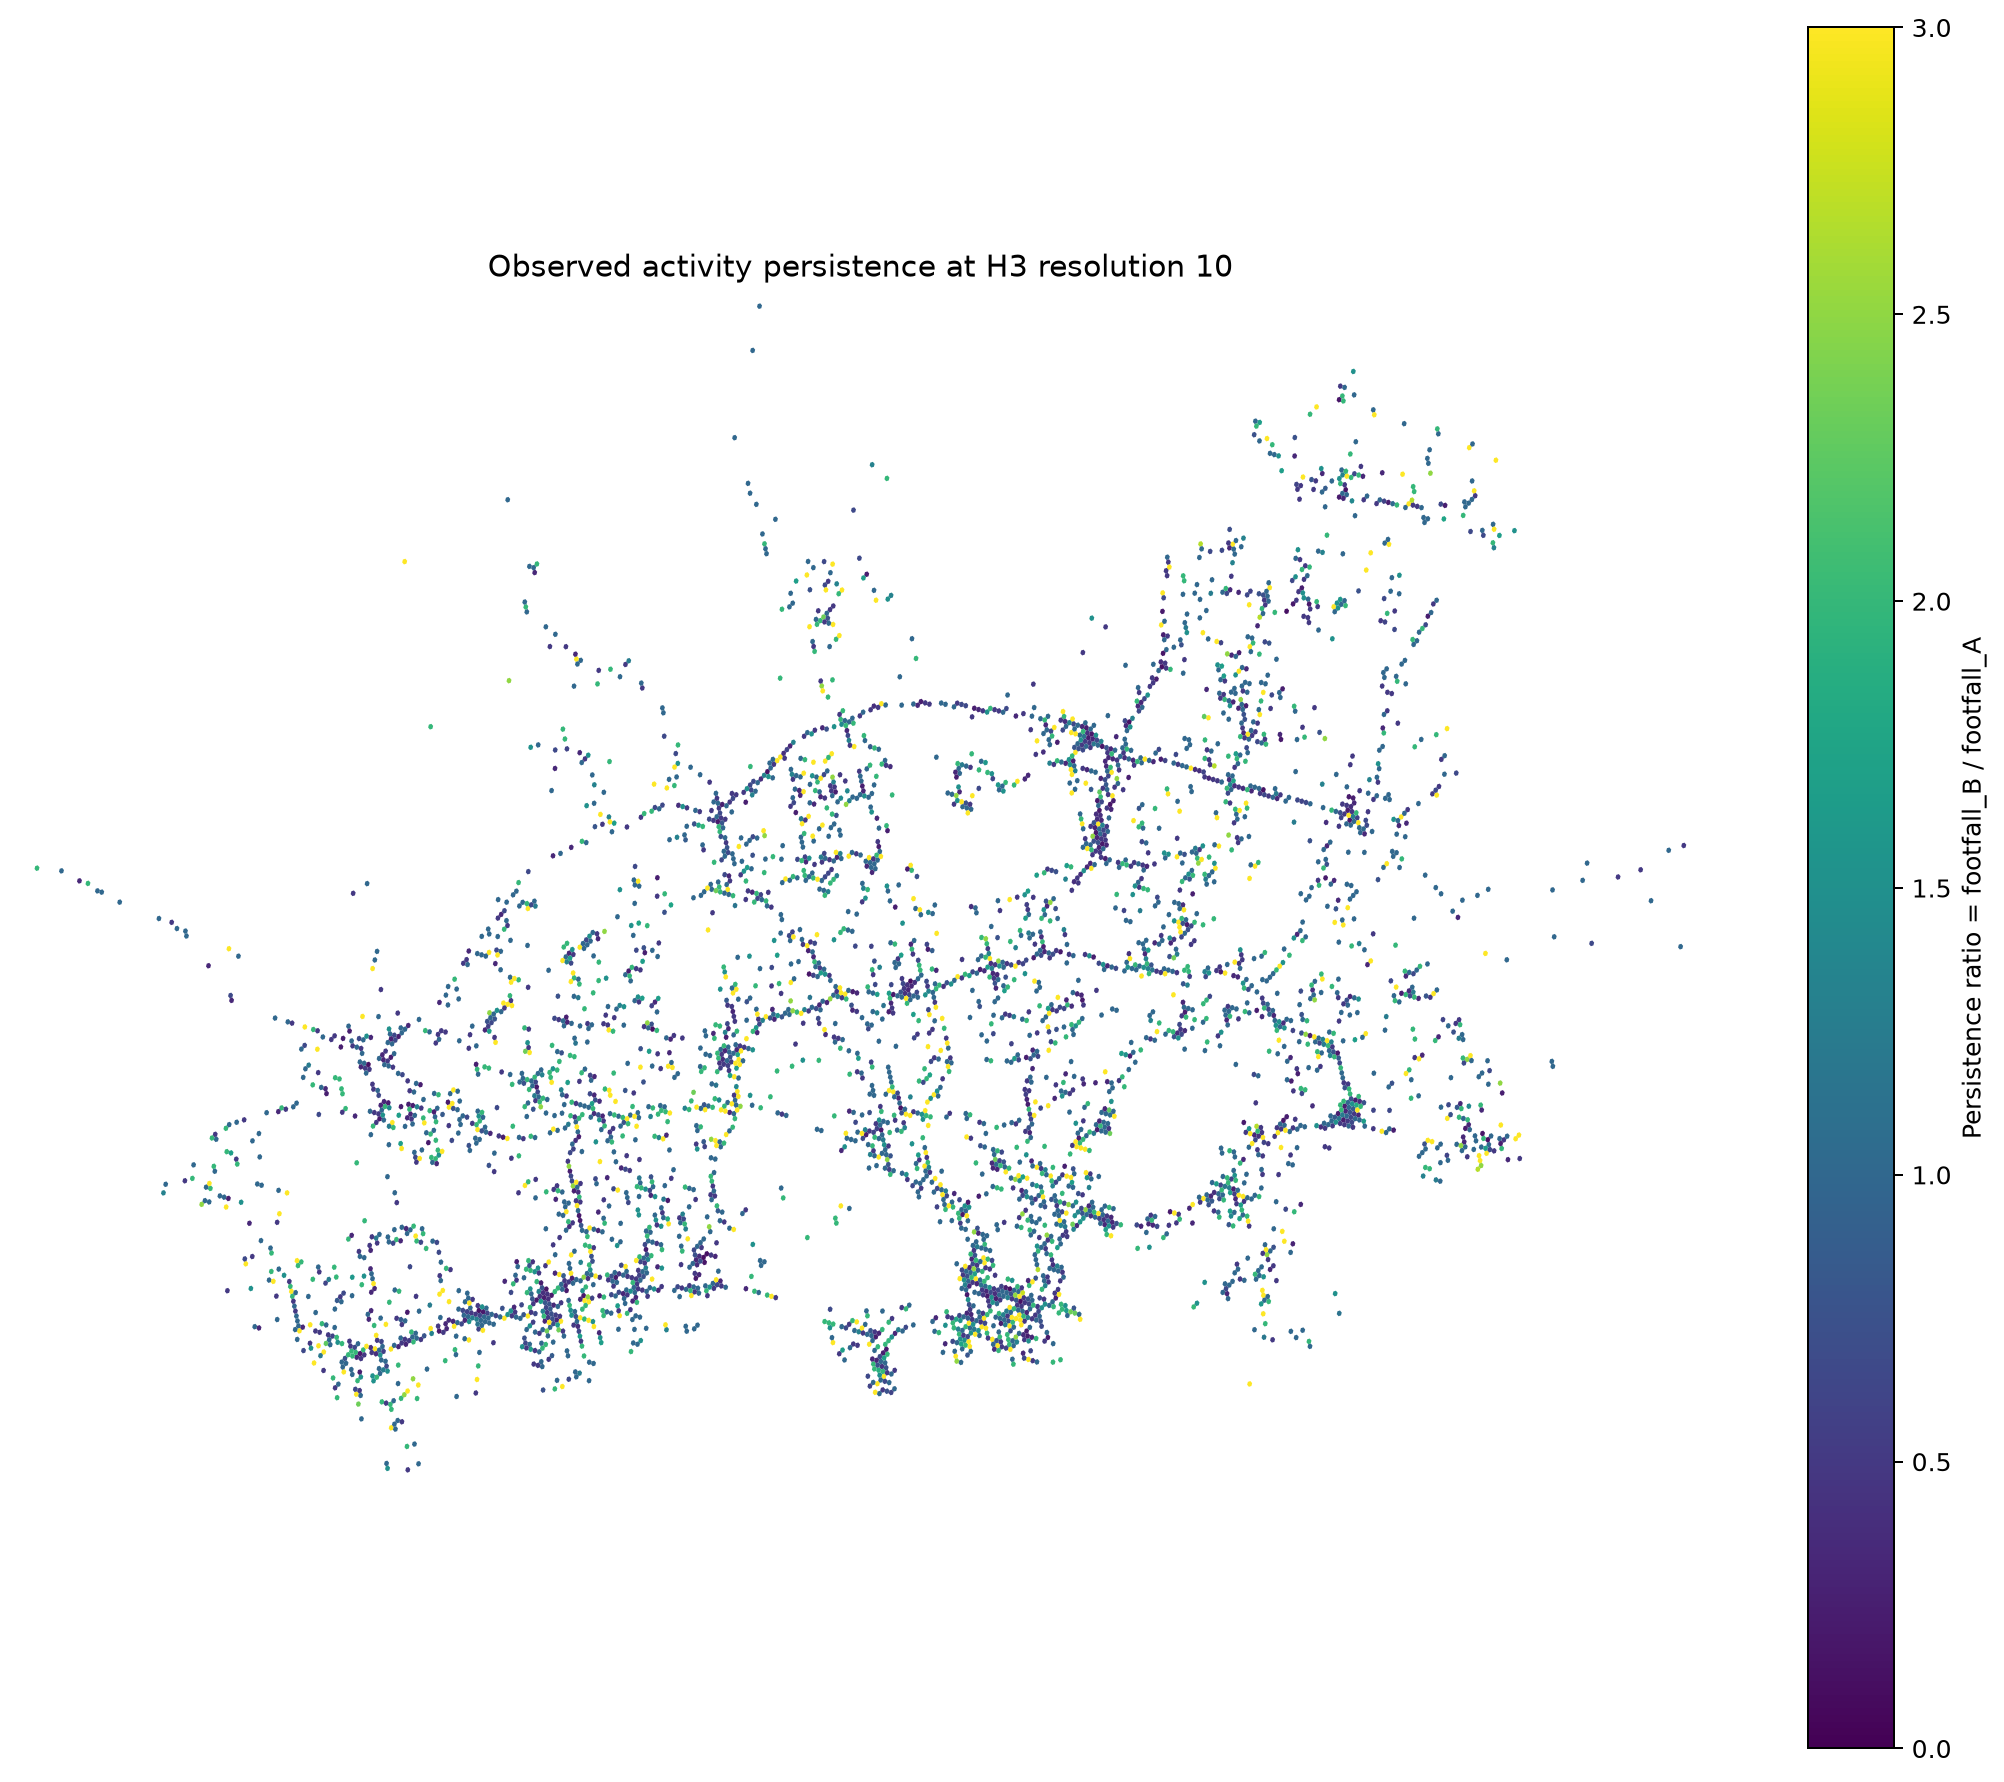

In [8]:
persistence_map = h3.dropna(
    subset=["persistence_ratio"]
).copy()

upper = np.nanpercentile(
    persistence_map["persistence_ratio"],
    95,
)

if not np.isfinite(upper):
    upper = 1.5

plot_h3_surface(
    persistence_map,
    column="persistence_ratio",
    title="Observed activity persistence at H3 resolution 10",
    legend_label="Persistence ratio = footfall_B / footfall_A",
    cmap="viridis",
    vmin=0,
    vmax=max(1.5, upper),
)


## 8. Map simple behavioural classes

Three classes only:
- decreased
- broadly stable
- increased


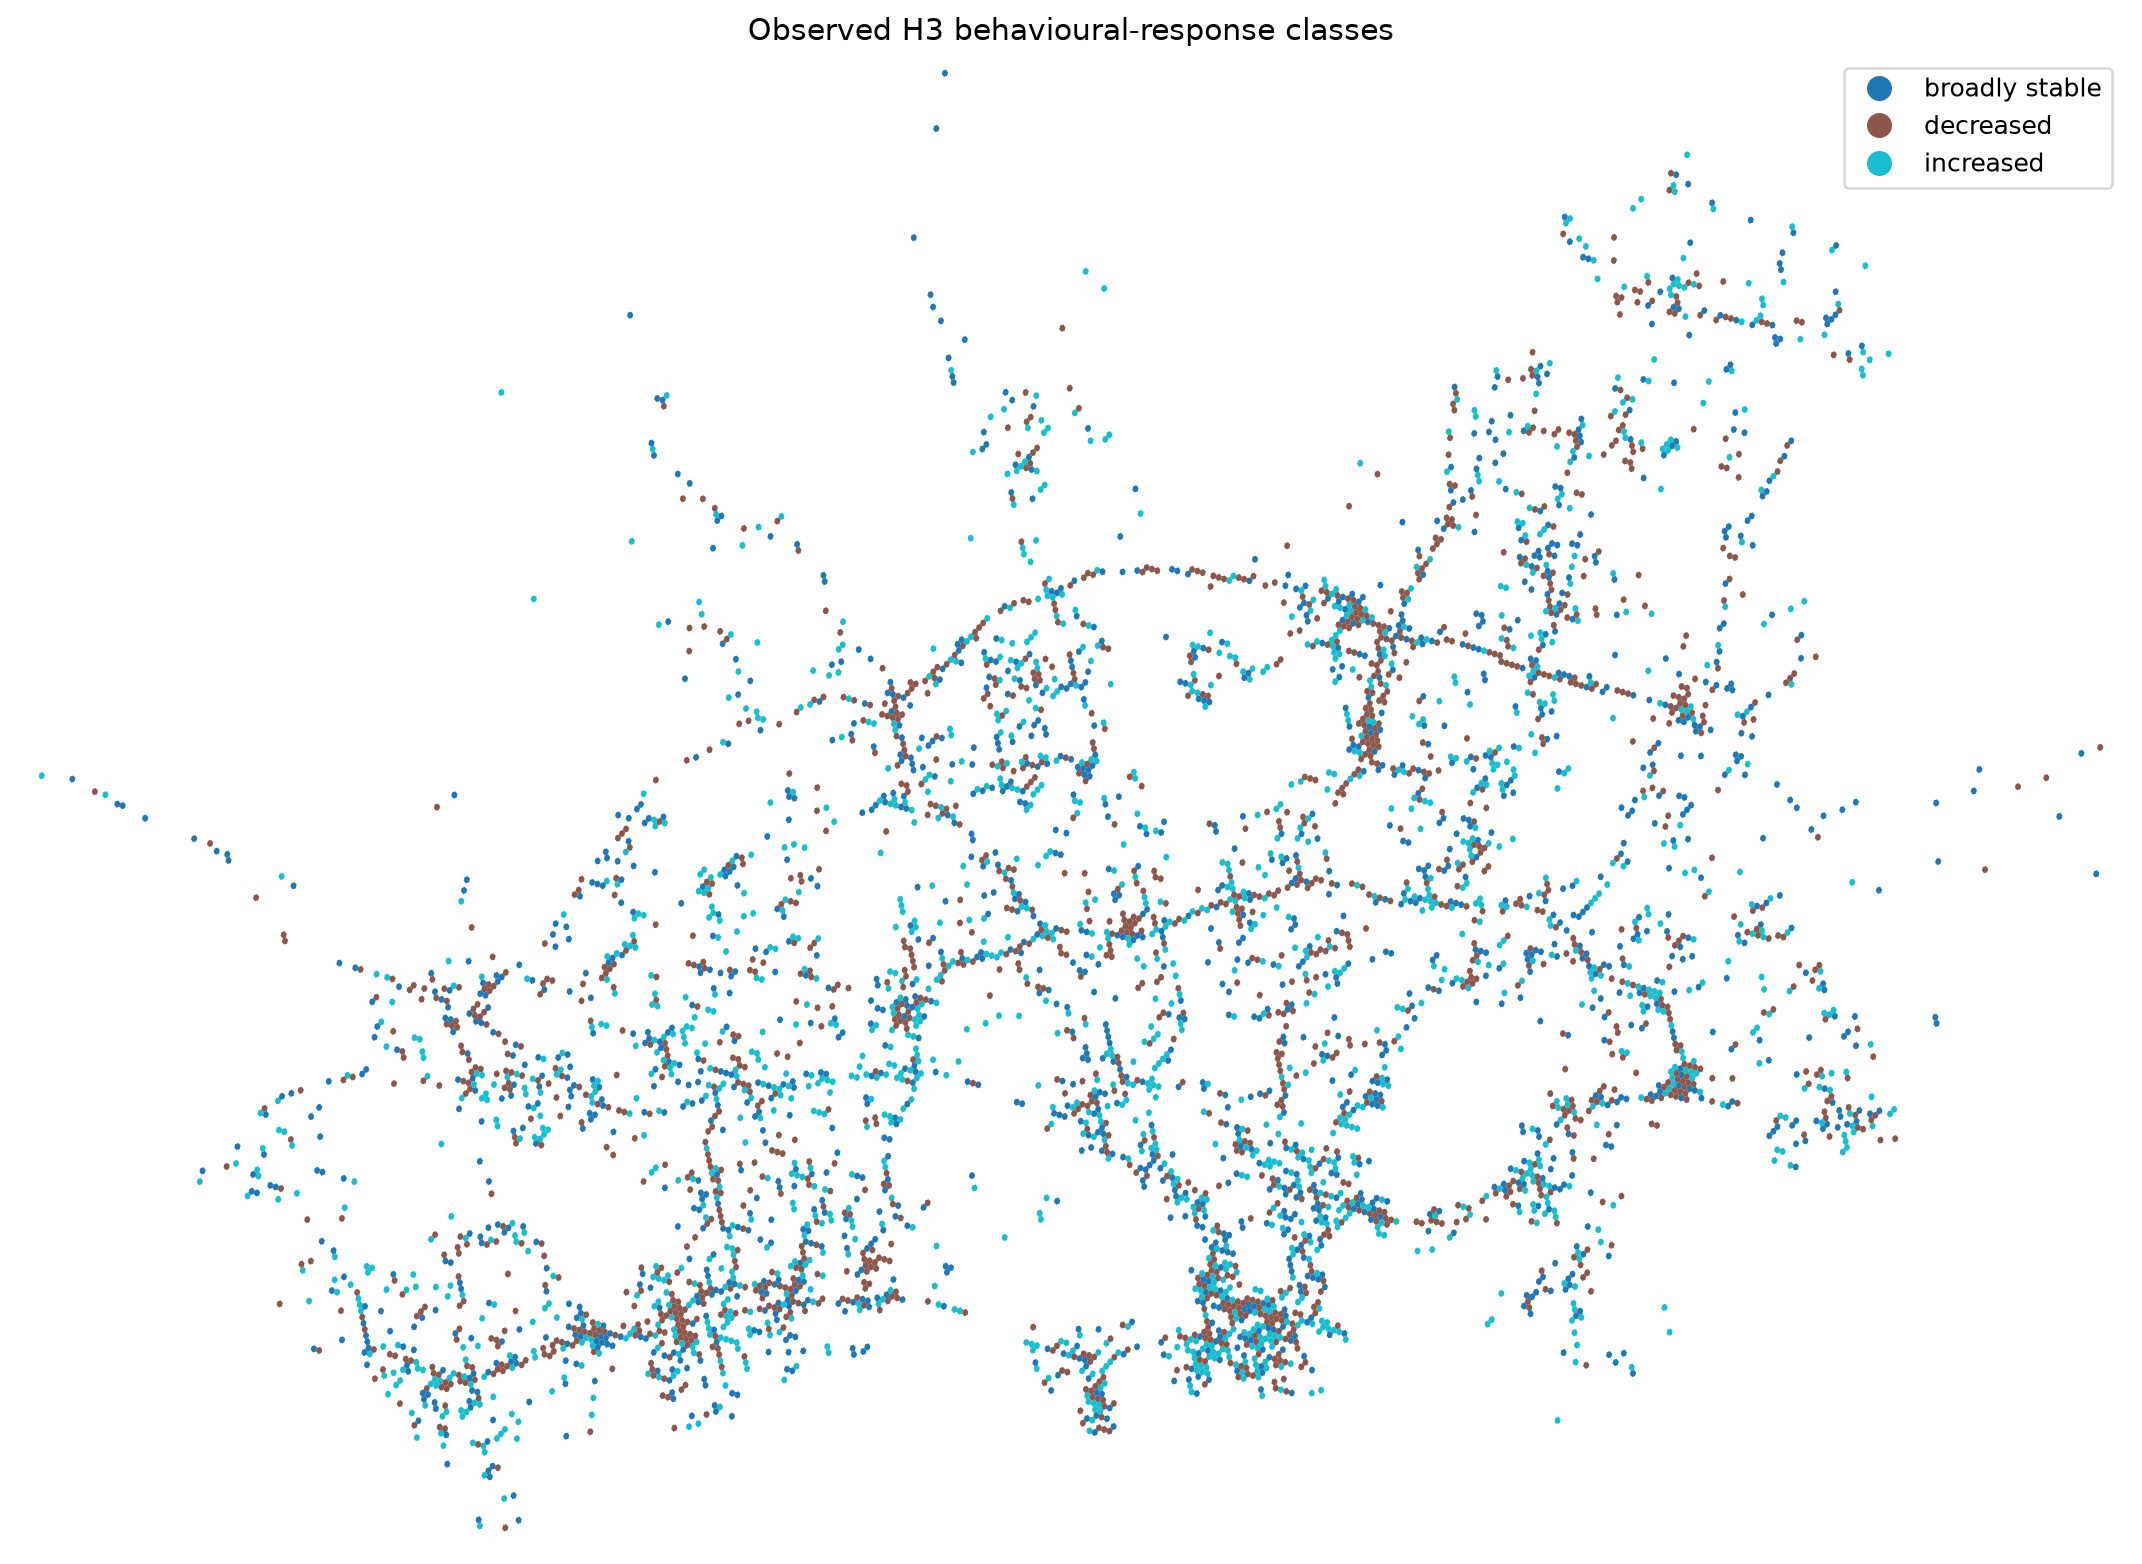

In [9]:
plot_h3_surface(
    h3,
    column="behavior_class",
    title="Observed H3 behavioural-response classes",
    legend_label="Behaviour class",
    categorical=True,
)


## 9. Map absolute activity loss

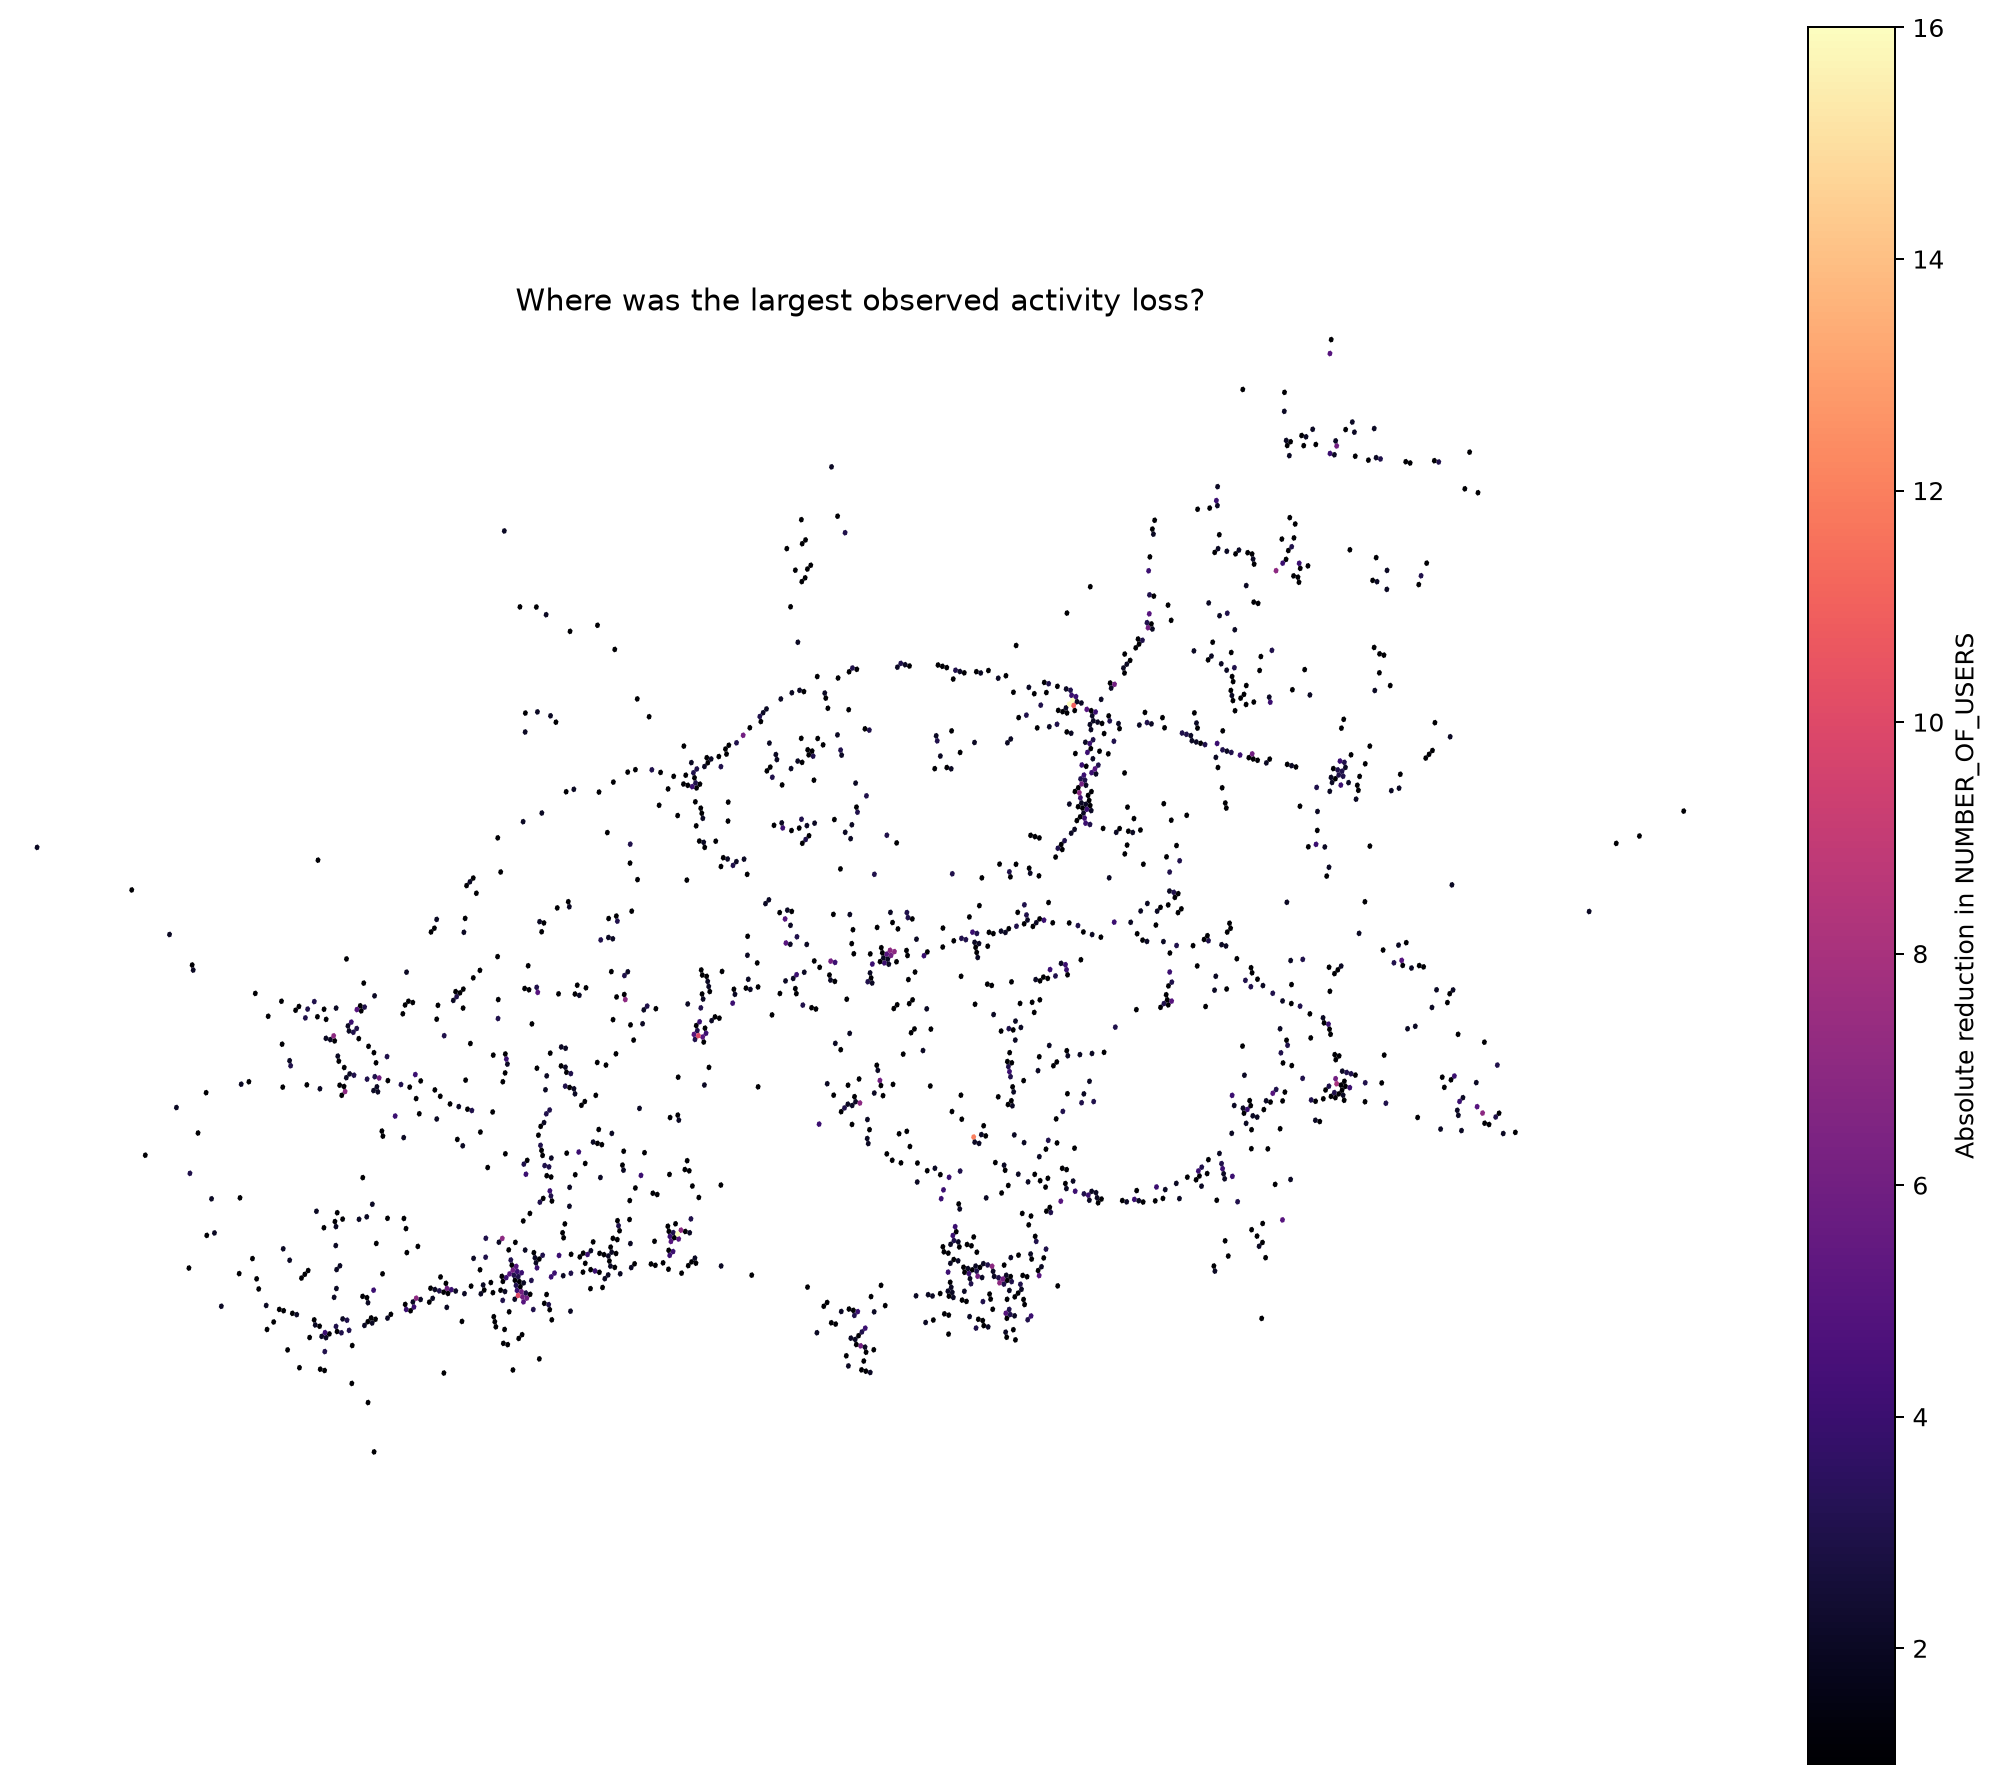

In [10]:
loss_map = h3.loc[
    h3["absolute_activity_loss"] > 0
].copy()

if not loss_map.empty:
    plot_h3_surface(
        loss_map,
        column="absolute_activity_loss",
        title="Where was the largest observed activity loss?",
        legend_label="Absolute reduction in NUMBER_OF_USERS",
        cmap="magma",
    )


## 10. Map absolute activity gain

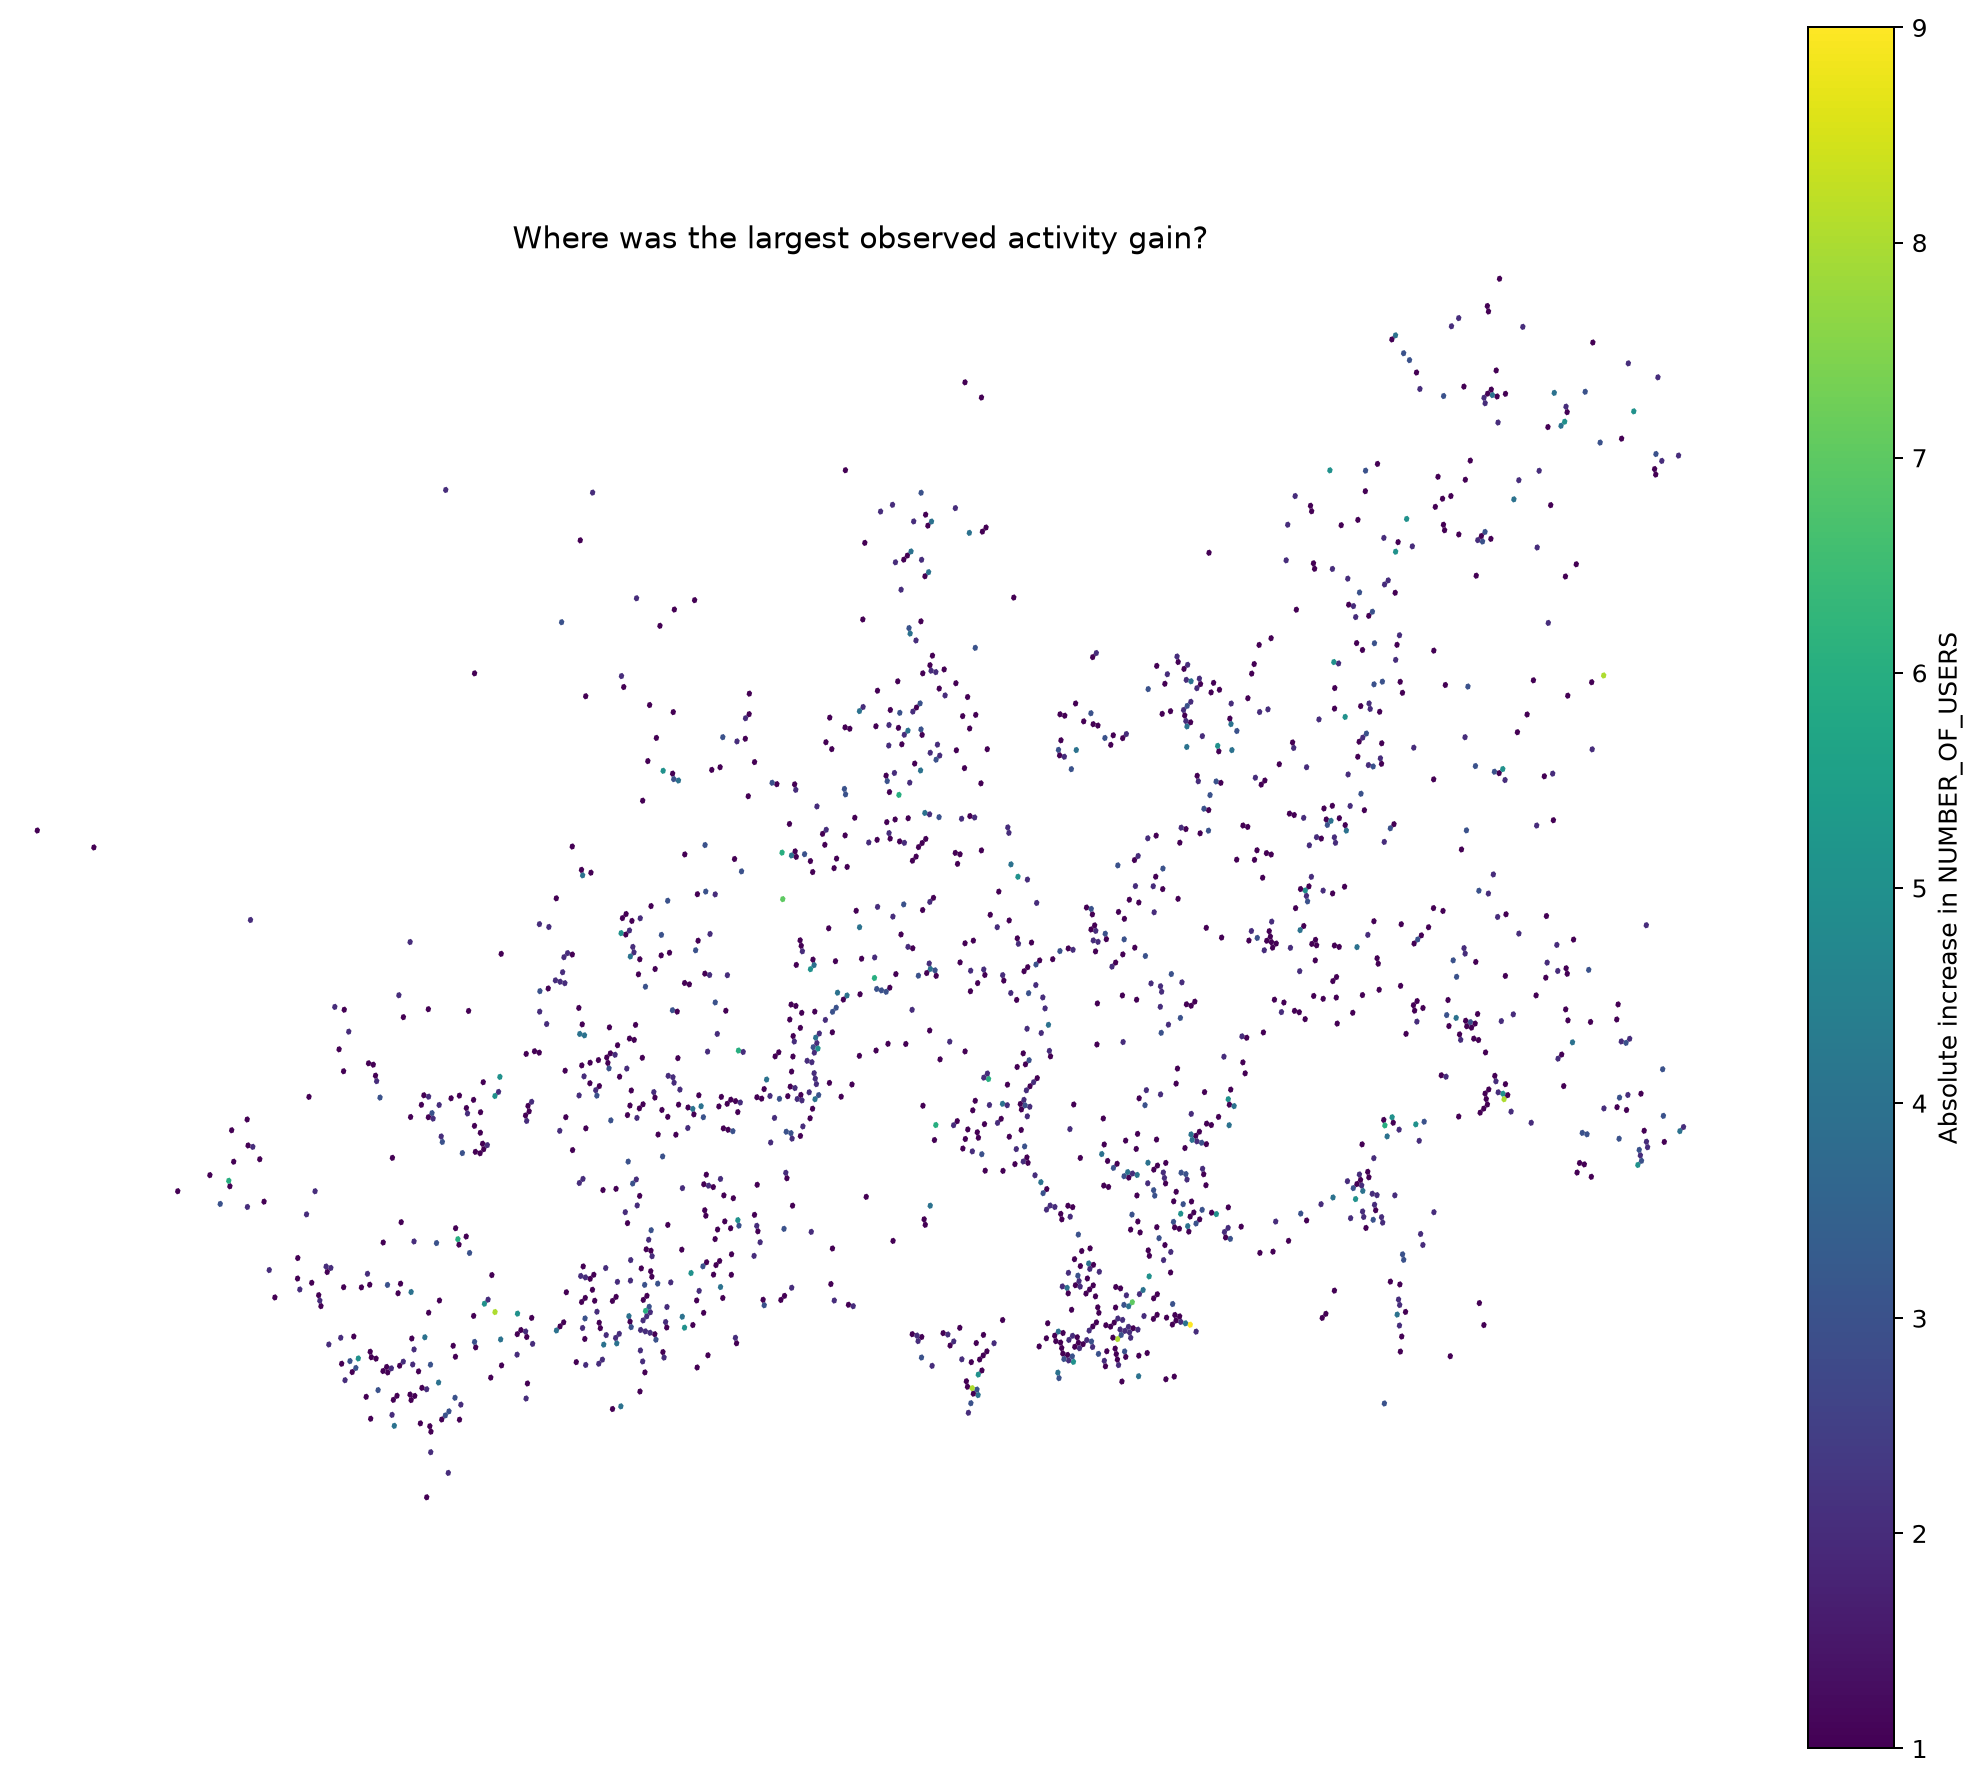

In [11]:
gain_map = h3.loc[
    h3["absolute_activity_gain"] > 0
].copy()

if not gain_map.empty:
    plot_h3_surface(
        gain_map,
        column="absolute_activity_gain",
        title="Where was the largest observed activity gain?",
        legend_label="Absolute increase in NUMBER_OF_USERS",
        cmap="viridis",
    )


## 11. Rank strongest H3 declines and persistence

In [12]:
top_declines = (
    h3.dropna(subset=["pct_change_footfall"])
    .sort_values("pct_change_footfall")
    [
        [
            "CODE",
            "footfall_A",
            "footfall_B",
            "absolute_activity_change",
            "pct_change_footfall",
            "persistence_ratio",
        ]
    ]
    .head(20)
)

top_persistent = (
    h3.dropna(subset=["persistence_ratio"])
    .sort_values("persistence_ratio", ascending=False)
    [
        [
            "CODE",
            "footfall_A",
            "footfall_B",
            "absolute_activity_change",
            "pct_change_footfall",
            "persistence_ratio",
        ]
    ]
    .head(20)
)

print("Strongest declines")
display(top_declines)

print("Strongest persistence / increase")
display(top_persistent)


Strongest declines


,CODE,footfall_A,footfall_B,absolute_activity_change,pct_change_footfall,persistence_ratio
4795,8a0899698d6ffff,18,2,-16,-88.888889,0.111111
4520,8a1126d46937fff,8,1,-7,-87.500000,0.125000
1120,8a1126d338cffff,8,1,-7,-87.500000,0.125000
4410,8a08996988b7fff,8,1,-7,-87.500000,0.125000
4212,8a1126d2188ffff,8,1,-7,-87.500000,0.125000
2168,8a0899688d0ffff,8,1,-7,-87.500000,0.125000
1942,8a1126c35367fff,8,1,-7,-87.500000,0.125000
4727,8a08996a1457fff,8,1,-7,-87.500000,0.125000
1821,8a08996d5d0ffff,7,1,-6,-85.714286,0.142857
4104,8a1126d720f7fff,7,1,-6,-85.714286,0.142857


Strongest persistence / increase


,CODE,footfall_A,footfall_B,absolute_activity_change,pct_change_footfall,persistence_ratio
641,8a1126d33ce7fff,1,9,8,800.0,9.0
2970,8a0899689c4ffff,1,8,7,700.0,8.0
3095,8a1126d26b9ffff,1,7,6,600.0,7.0
765,8a1126d20547fff,1,7,6,600.0,7.0
2983,8a08996d0d6ffff,1,7,6,600.0,7.0
1068,8a089968598ffff,1,6,5,500.0,6.0
516,8a089968b837fff,1,6,5,500.0,6.0
3368,8a08996d260ffff,1,6,5,500.0,6.0
4121,8a0899685877fff,1,6,5,500.0,6.0
4197,8a1126d0600ffff,1,6,5,500.0,6.0


## 12. Baseline activity vs behavioural change

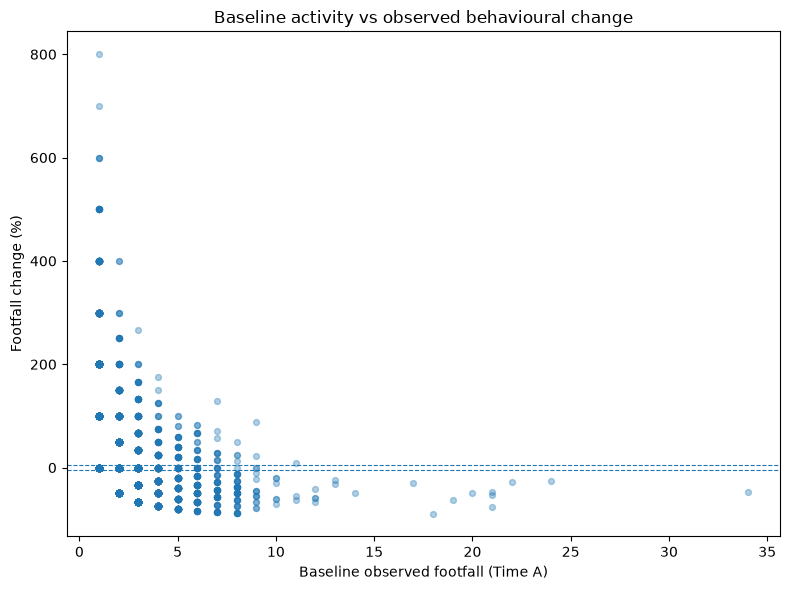

In [13]:
scatter = h3.dropna(
    subset=["footfall_A", "pct_change_footfall"]
).copy()

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    scatter["footfall_A"],
    scatter["pct_change_footfall"],
    alpha=0.35,
    s=18,
)

ax.axhline(
    -STABLE_THRESHOLD_PCT,
    linestyle="--",
    linewidth=0.8,
)

ax.axhline(
    STABLE_THRESHOLD_PCT,
    linestyle="--",
    linewidth=0.8,
)

ax.set_xlabel("Baseline observed footfall (Time A)")
ax.set_ylabel("Footfall change (%)")
ax.set_title("Baseline activity vs observed behavioural change")

plt.tight_layout()
plt.show()


## 13. Higher-baseline-activity H3 cells only

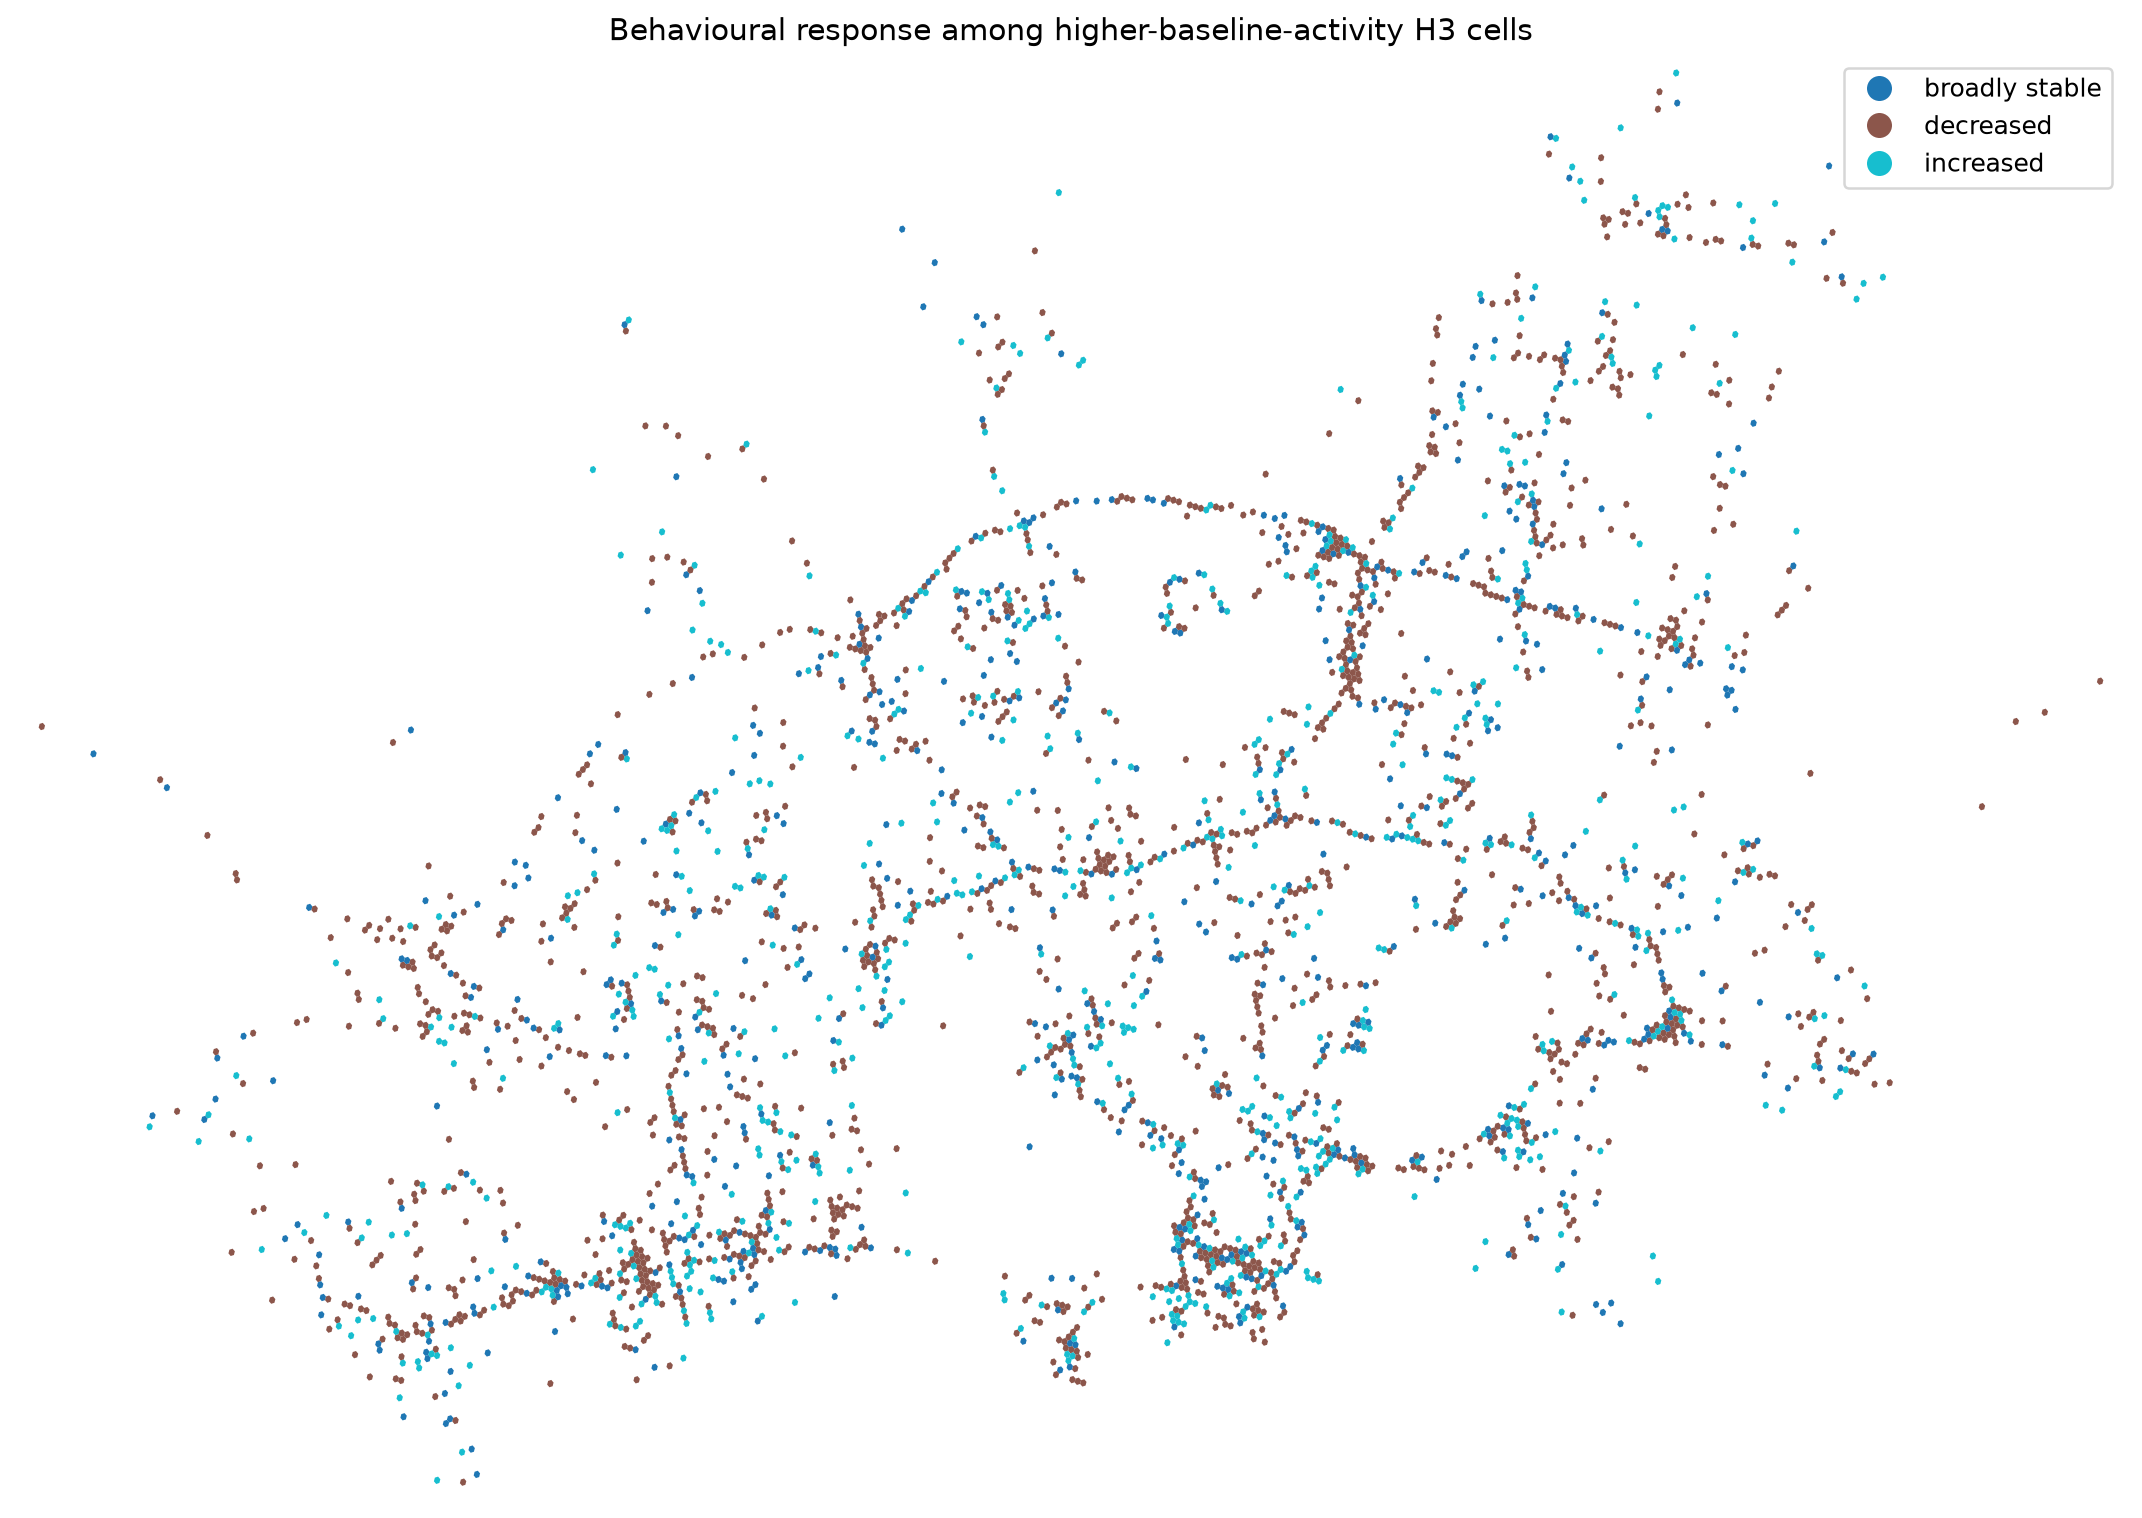

Baseline median NUMBER_OF_USERS: 2.0


In [14]:
baseline_median = h3["footfall_A"].median()

high_activity = h3.loc[
    h3["footfall_A"] >= baseline_median
].copy()

plot_h3_surface(
    high_activity,
    column="behavior_class",
    title="Behavioural response among higher-baseline-activity H3 cells",
    legend_label="Behaviour class",
    categorical=True,
)

print("Baseline median NUMBER_OF_USERS:", baseline_median)


## 14. Secondary neighbourhood summary

Neighbourhoods are retained only as a **summary geography**.  
The H3 response remains the primary analysis.


In [15]:
units = gpd.read_file(
    helsinki.mobility.neighbourhoods
)

units["unit_id"] = (
    units["Neighbourhood_unit_ID"].astype("Int64")
)

neighbourhoods = units[
    [
        "unit_id",
        "Neighbourhood_name",
        "Municipality_name",
        "geometry",
    ]
].copy()

h3_proj = h3.to_crs(neighbourhoods.crs).copy()

h3_points = h3_proj.copy()
h3_points["geometry"] = h3_points.geometry.representative_point()

joined = gpd.sjoin(
    h3_points,
    neighbourhoods,
    predicate="within",
    how="left",
)

matched = joined.loc[
    joined["unit_id"].notna()
].copy()

print("Matched H3 cells:", len(matched), "/", len(joined))


Matched H3 cells: 4873 / 4873


## 15. Aggregate behavioural response by neighbourhood

In [16]:
neighbourhood_summary = (
    matched
    .groupby(
        [
            "unit_id",
            "Neighbourhood_name",
            "Municipality_name",
        ],
        as_index=False,
    )
    .agg(
        n_h3_cells=("CODE", "nunique"),
        footfall_A_sum=("footfall_A", "sum"),
        footfall_B_sum=("footfall_B", "sum"),
        median_h3_pct_change=("pct_change_footfall", "median"),
        mean_h3_pct_change=("pct_change_footfall", "mean"),
        median_persistence_ratio=("persistence_ratio", "median"),
    )
)

neighbourhood_summary["footfall_sum_pct_change"] = np.where(
    neighbourhood_summary["footfall_A_sum"] > 0,
    100
    * (
        neighbourhood_summary["footfall_B_sum"]
        - neighbourhood_summary["footfall_A_sum"]
    )
    / neighbourhood_summary["footfall_A_sum"],
    np.nan,
)

display(
    neighbourhood_summary.sort_values(
        "footfall_sum_pct_change"
    ).head(20)
)


,unit_id,Neighbourhood_name,Municipality_name,n_h3_cells,footfall_A_sum,footfall_B_sum,median_h3_pct_change,mean_h3_pct_change,median_persistence_ratio,footfall_sum_pct_change
17,492021211,Tapiolan Keskus,Espoo,23,91,44,-33.333333,-19.516908,0.666667,-51.648352
66,496063631,Karvasmäki,Espoo,19,59,29,-50.000000,-41.478697,0.500000,-50.847458
216,918801592,Puroniitty,Helsinki,1,2,1,-50.000000,-50.000000,0.500000,-50.000000
198,917701455,Marjaniemi,Helsinki,1,2,1,-50.000000,-50.000000,0.500000,-50.000000
136,913303213,Kyläsaari,Helsinki,1,2,1,-50.000000,-50.000000,0.500000,-50.000000
94,911103202,Lapinlahti,Helsinki,4,13,7,-50.000000,-32.500000,0.500000,-46.153846
251,924069000,Helsingin pitäjän kirkonkylä,Vantaa,5,13,7,-50.000000,-45.000000,0.500000,-46.153846
199,917701456,Roihupelto,Helsinki,10,29,16,-50.000000,-35.833333,0.500000,-44.827586
19,492021213,Otsolahti,Espoo,2,7,4,-25.000000,-25.000000,0.750000,-42.857143
58,496061611,Kirkkojärvi,Espoo,20,41,25,-33.333333,-28.750000,0.666667,-39.024390


## 16. Native H3 resolution-10 behavioural response surface

This is the main spatial summary.

The map keeps the **actual Locomizer H3 resolution-10 polygons**, but renders them as a continuous filled tessellation with no visible gaps between cells.

That makes the result visually closer to a raster/grid map while preserving the H3 geography.


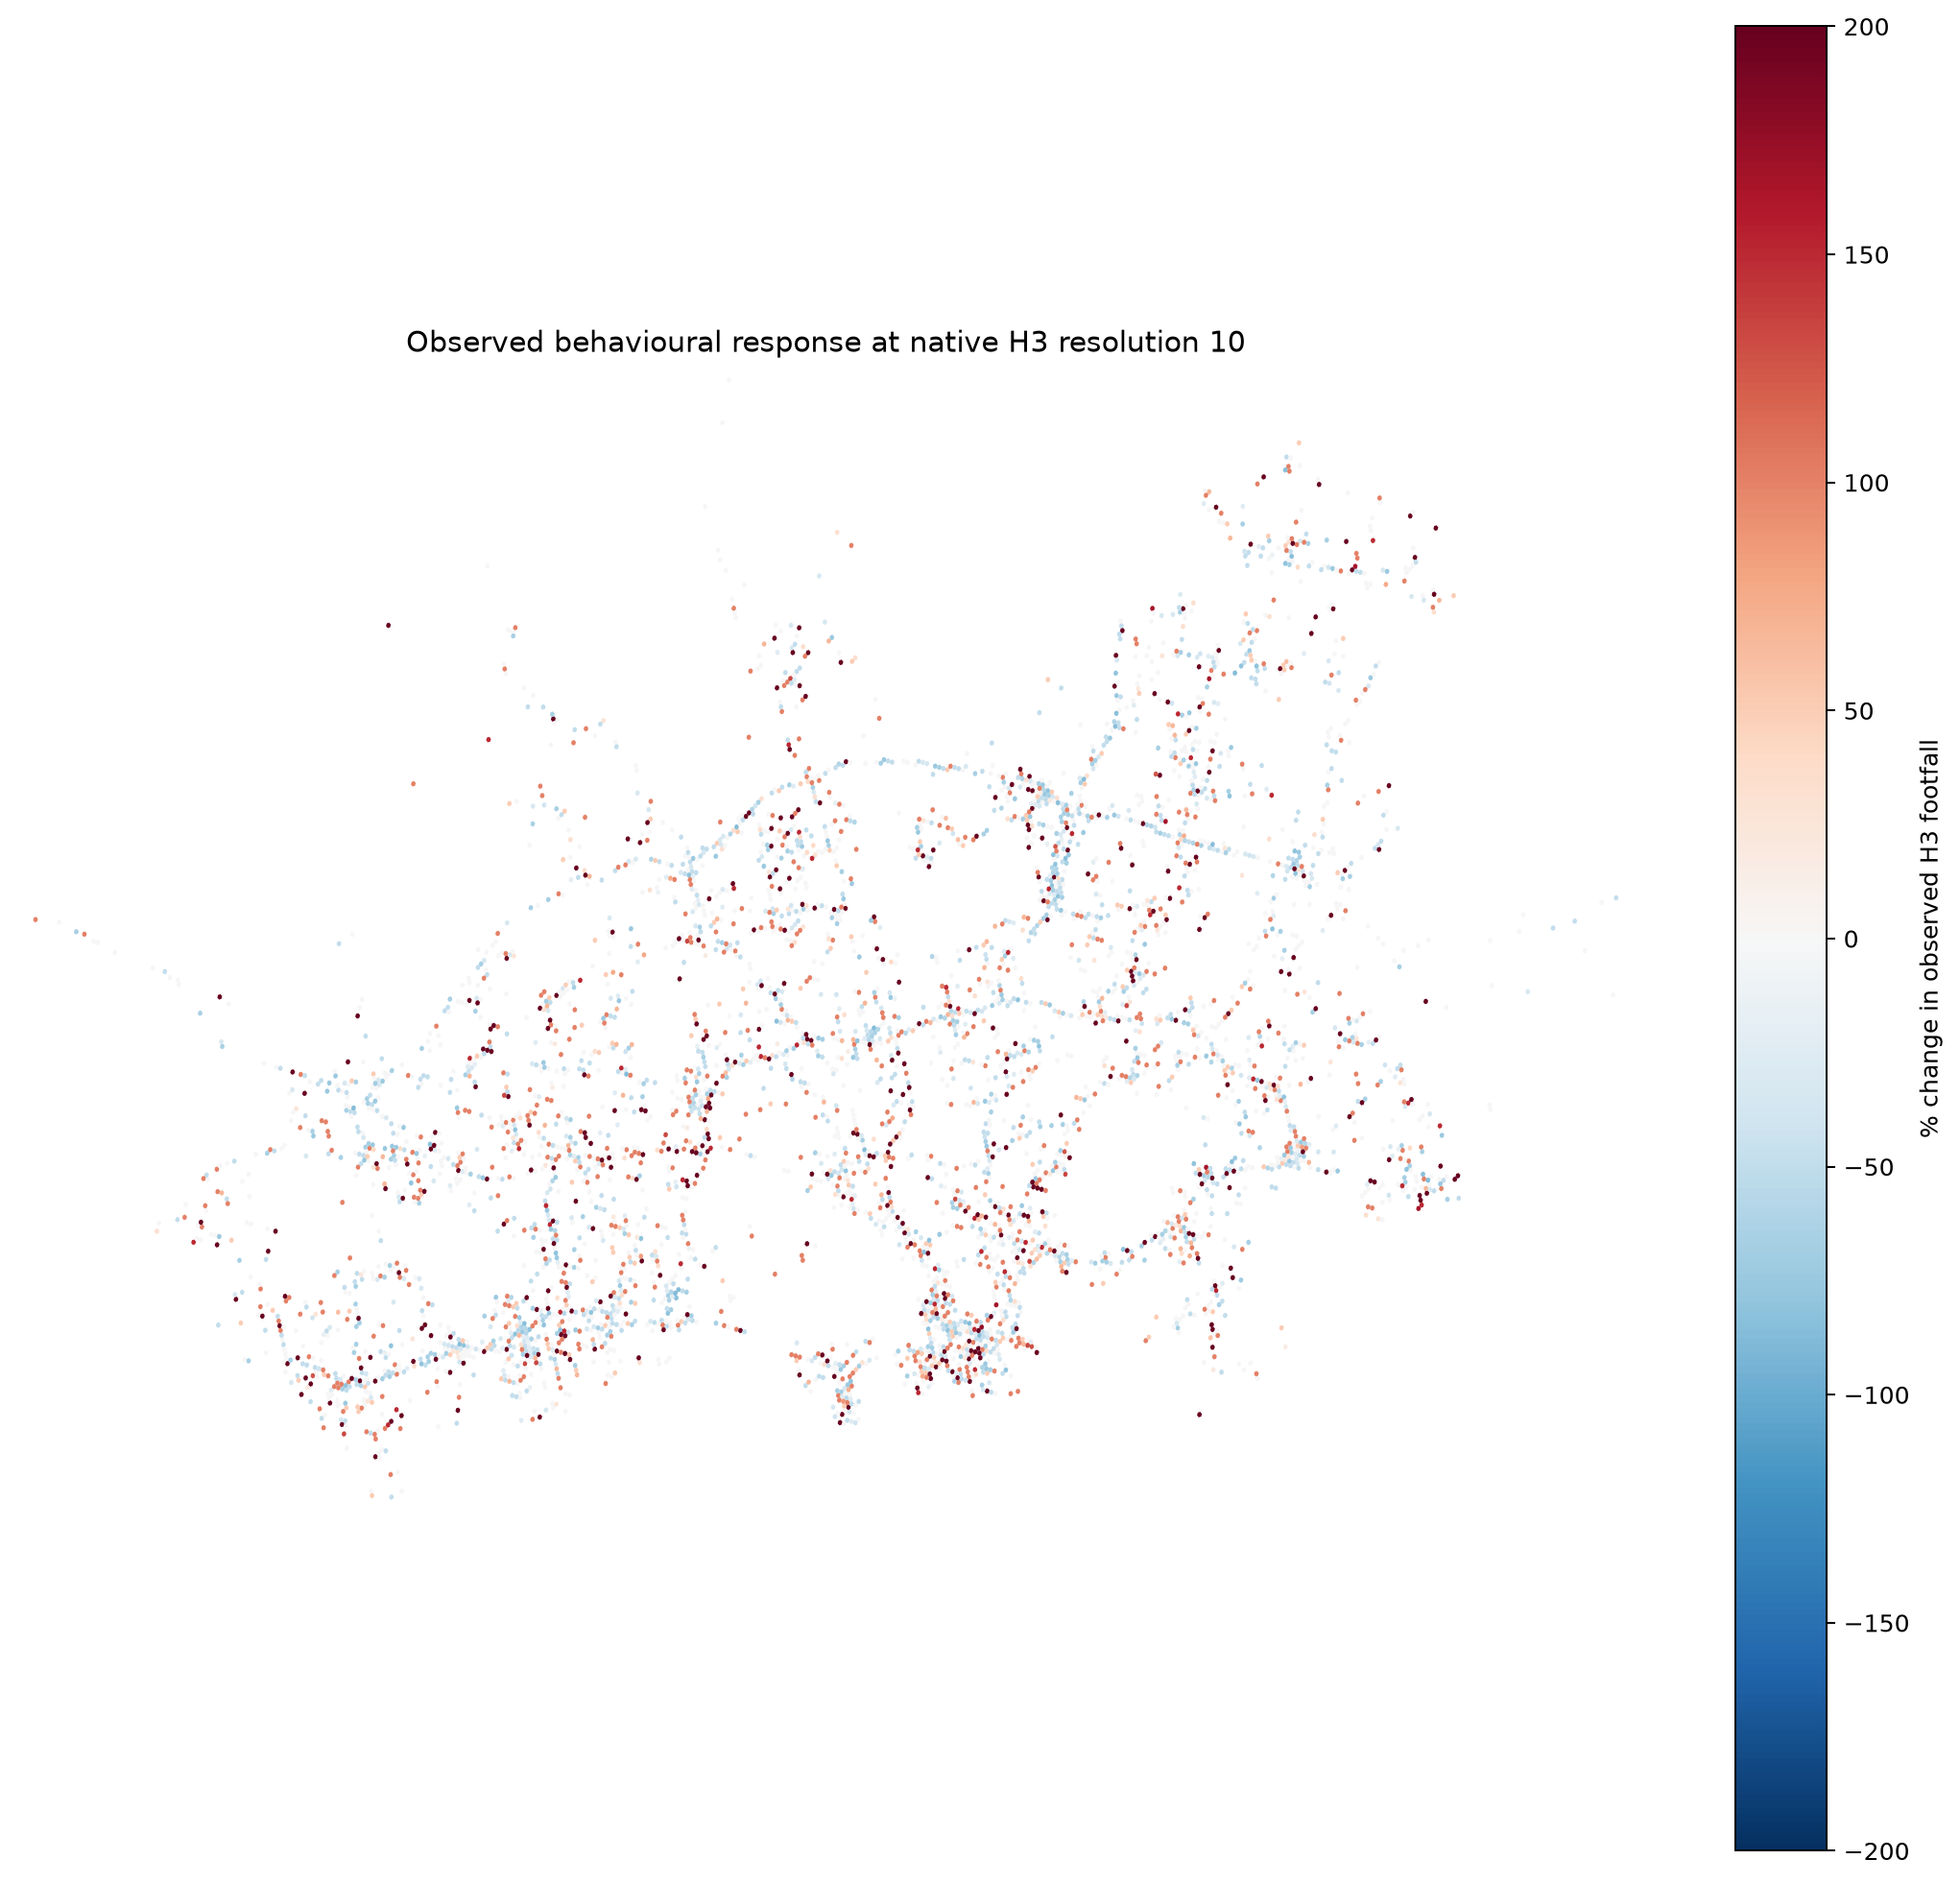

In [17]:
h3_map = h3.dropna(
    subset=["pct_change_footfall"]
).copy()

limit = np.nanpercentile(
    np.abs(h3_map["pct_change_footfall"]),
    95,
)

if not np.isfinite(limit) or limit == 0:
    limit = 1

plot_h3_surface(
    h3_map,
    column="pct_change_footfall",
    title="Observed behavioural response at native H3 resolution 10",
    legend_label="% change in observed H3 footfall",
    cmap="RdBu_r",
    vmin=-limit,
    vmax=limit,
    figsize=(12, 11),
)


## 17. Does the selected PM₂.₅ event pair represent worsening air?

In [18]:
current_delta_pm25 = (
    h3["regional_delta_pm25_median"]
    .dropna()
    .iloc[0]
)

print(
    "Regional median ΔPM2.5:",
    current_delta_pm25,
    "µg/m³",
)

if current_delta_pm25 > 0:
    print("The selected pair represents worsening regional PM2.5.")
elif current_delta_pm25 < 0:
    print("The selected pair represents improving regional PM2.5.")
else:
    print("Regional PM2.5 did not change.")


Regional median ΔPM2.5: -2.8499999999999996 µg/m³
The selected pair represents improving regional PM2.5.


## 18. Stronger same-hour PM₂.₅ event candidates

In [19]:
if PM25_CANDIDATE_PAIRS.exists():
    candidate_pairs = pd.read_csv(
        PM25_CANDIDATE_PAIRS,
        parse_dates=["time_A", "time_B"],
    )

    worsening = (
        candidate_pairs.loc[
            candidate_pairs["delta_pm25"] > 0
        ]
        .sort_values(
            "delta_pm25",
            ascending=False,
        )
    )

    display(worsening.head(15))
else:
    print(
        "Candidate-pairs file not found. Run Stage 00 first."
    )


,hour,time_A,time_B,pm25_A_median,pm25_B_median,delta_pm25,abs_delta_pm25,n_stations_A,n_stations_B


## 19. Behavioural adaptation screening table

This ranks cells using both:
- baseline activity volume;
- magnitude of behavioural change.

The purpose is to avoid overemphasizing extreme percentages from tiny baseline values.


In [20]:
screening = h3[
    [
        "CODE",
        "footfall_A",
        "footfall_B",
        "absolute_activity_change",
        "absolute_activity_loss",
        "absolute_activity_gain",
        "pct_change_footfall",
        "persistence_ratio",
        "behavior_class",
        "regional_delta_pm25_median",
    ]
].copy()

screening["baseline_activity_rank"] = (
    screening["footfall_A"]
    .rank(pct=True, method="average")
)

screening["change_magnitude_rank"] = (
    screening["pct_change_footfall"]
    .abs()
    .rank(pct=True, method="average")
)

screening["behavioral_salience_score"] = (
    screening["baseline_activity_rank"]
    * screening["change_magnitude_rank"]
)

display(
    screening.sort_values(
        "behavioral_salience_score",
        ascending=False,
    ).head(30)
)


,CODE,footfall_A,footfall_B,absolute_activity_change,absolute_activity_loss,absolute_activity_gain,pct_change_footfall,persistence_ratio,behavior_class,regional_delta_pm25_median,baseline_activity_rank,change_magnitude_rank,behavioral_salience_score
29,8a1126d15d77fff,7,16,9,0,9,128.571429,2.285714,increased,-2.85,0.974759,0.900882,0.878143
1982,8a1126d3315ffff,4,11,7,0,7,175.000000,2.750000,increased,-2.85,0.853478,0.915658,0.781494
3597,8a089968b757fff,4,10,6,0,6,150.000000,2.500000,increased,-2.85,0.853478,0.908783,0.775627
4468,8a1126d701affff,4,9,5,0,5,125.000000,2.250000,increased,-2.85,0.853478,0.900369,0.768446
3780,8a1126d2905ffff,4,9,5,0,5,125.000000,2.250000,increased,-2.85,0.853478,0.900369,0.768446
378,8a1126d00337fff,4,9,5,0,5,125.000000,2.250000,increased,-2.85,0.853478,0.900369,0.768446
480,8a08996b0967fff,4,9,5,0,5,125.000000,2.250000,increased,-2.85,0.853478,0.900369,0.768446
3897,8a1126d1c027fff,5,10,5,0,5,100.000000,2.000000,increased,-2.85,0.921404,0.833265,0.767773
3403,8a1126d544c7fff,5,10,5,0,5,100.000000,2.000000,increased,-2.85,0.921404,0.833265,0.767773
4795,8a0899698d6ffff,18,2,-16,16,0,-88.888889,0.111111,decreased,-2.85,0.998358,0.766366,0.765108


## 20. Save outputs

In [21]:
h3_csv = (
    OUTPUT_DIR / "stage06_h3_behavioural_response.csv"
)

h3_gpkg = (
    OUTPUT_DIR / "stage06_h3_behavioural_response.gpkg"
)

neighbourhood_csv = (
    OUTPUT_DIR / "stage06_neighbourhood_summary.csv"
)

neighbourhood_gpkg = (
    OUTPUT_DIR / "stage06_neighbourhood_summary.gpkg"
)

screening_csv = (
    OUTPUT_DIR / "stage06_h3_behavioural_screening.csv"
)

# Rebuild neighbourhood geometry here explicitly so the save cell
# is independent of any earlier visualization cell.
neighbourhood_map = neighbourhoods.merge(
    neighbourhood_summary,
    on=[
        "unit_id",
        "Neighbourhood_name",
        "Municipality_name",
    ],
    how="left",
)

h3.drop(
    columns="geometry"
).to_csv(
    h3_csv,
    index=False,
)

h3.to_file(
    h3_gpkg,
    layer="h3_behavioural_response",
    driver="GPKG",
)

neighbourhood_summary.to_csv(
    neighbourhood_csv,
    index=False,
)

neighbourhood_map.to_file(
    neighbourhood_gpkg,
    layer="neighbourhood_summary",
    driver="GPKG",
)

screening.to_csv(
    screening_csv,
    index=False,
)

print("Saved:")
for path in [
    h3_csv,
    h3_gpkg,
    neighbourhood_csv,
    neighbourhood_gpkg,
    screening_csv,
]:
    print(" -", path)


Saved:
 - ../outputs/v3/06_h3_behavioural_response/stage06_h3_behavioural_response.csv
 - ../outputs/v3/06_h3_behavioural_response/stage06_h3_behavioural_response.gpkg
 - ../outputs/v3/06_h3_behavioural_response/stage06_neighbourhood_summary.csv
 - ../outputs/v3/06_h3_behavioural_response/stage06_neighbourhood_summary.gpkg
 - ../outputs/v3/06_h3_behavioural_response/stage06_h3_behavioural_screening.csv


# Interpretation and next step

This stage now prioritizes **observed behavioural change at H3 level**.

The study logic is:

**Regional environmental change → observed H3-level activity response → identify decline, persistence, and increase → focus on high-activity places → only then use CAFEIN, accessibility, and transport-poverty metrics to explain possible constraints on adaptation.**

CAFEIN should therefore become an explanatory mobility-context layer in a later stage rather than the behavioural outcome itself.
